In [ ]:
"""
Author: Ruby Lieber 
Affiliation: University of Bristol
Date: 28/08/2025

Description:
This notebook calculates the signal to noise ratio for mean temperature over Brazil during the period 2000-2018.
"""

>Methods:
>1. Fit a quartic polynomial to temperatures at each grid point over the entire period with continuous annual temperatures (smooth fit).
>2. Difference in the smoothed fit values between first and last year defines the signal.
>3. Standard deviation of residuals from smooth fit defines the noise.
>4. Signal-to-noise is simply the ratio of signal and noise.
>5. Note that this is a simplified estimate of the signal-to-noise, with the caveat that it relies on the smooth fit to define the signal. This probably implies a slight underestimate of the variability and slight overestimate of the S/N.
>
> Reference: https://www.climate-lab-book.ac.uk/2014/signal-noise-emergence/

In [ ]:
# Imports 
import os
import re
import xarray as xr
import numpy as np
import geopandas as gpd
from exactextract import exact_extract
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import gridspec

In [2]:
# Read in bias corrected model and downscaled data (hist and hist-nat)

base_path = "/bp1/geog-tropical/data/BREATHE/downscale_damip_05_mask/"

# Find all tas files
tas_files = glob(os.path.join(base_path, "tas_*.nc"))

# Pattern to extract model, run, and ensemble
pattern = re.compile(
    r"tas_(?P<model>[^_]+)_(?P<run>[^_]+)_(?P<ensemble>r\d+i\d+p\d+f\d+)_downscaled_05_masked_2000_2018\.nc"
)

# Group files by (model, run)
grouped_files = defaultdict(list)
for f in tas_files:
    match = pattern.search(os.path.basename(f))
    if match:
        key = (match["model"], match["run"])
        grouped_files[key].append((match["ensemble"], f))

# Read and combine files into datasets
datasets = {}
for (model, run), ens_files in grouped_files.items():
    # Sort by ensemble 
    ens_files.sort()
    
    # Load all files and assign ensemble coord
    members = []
    for ens_name, f in ens_files:
        ds = xr.open_dataset(f)
        ds = ds.expand_dims(ensemble=[ens_name])
        members.append(ds)

    combined = xr.concat(members, dim="ensemble")
    datasets[(model, run)] = combined

In [3]:
# Resample to annual
annual = {k: v.copy(deep=True) for k, v in datasets.items()}
for k in annual:
    ds = annual[k]
    
    # Ensure time is datetime64
    if not np.issubdtype(ds.time.dtype, np.datetime64):
        ds = xr.decode_cf(ds)

    # Select tas variable and resample to annual (calendar year)
    tas_annual = ds["tas"].resample(time="YS").mean()

    # Replace dataset with only the annual tas variable
    annual[k] = tas_annual

In [5]:
# Ensemble means 
historical = {}
hist_nat = {}

for (model, run), da in annual.items():
    mean_ens = da.mean(dim='ensemble')
    if run == 'historical':
        historical[model] = mean_ens
    elif run == 'hist-nat':
        hist_nat[model] = mean_ens

# Combine into one dataset with models as variables
historical_da = xr.concat(list(historical.values()), dim='model')
historical_da['model'] = list(historical.keys())

hist_nat_da = xr.concat(list(hist_nat.values()), dim='model')
hist_nat_da['model'] = list(hist_nat.keys())

In [6]:
# Compute multi model mean 
hist_nat_mmm = hist_nat_da.mean(dim="model")
historical_mmm = historical_da.mean(dim="model")

In [ ]:
# Signal to noise ratio
time_numeric = np.arange(historical_mmm.sizes['time'])  

# Function to fit quartic polynomial and return fitted values
def fit_quartic(y):
    if np.all(np.isnan(y)):
        return np.full_like(y, np.nan)
    coeffs = np.polyfit(time_numeric, y, deg=4)
    return np.polyval(coeffs, time_numeric)

# Apply along the 'time' dimension
fitted = xr.apply_ufunc(
    fit_quartic,
    historical_mmm,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',  # optional if using dask
    output_dtypes=[hist_nat_mmm.dtype]
)

signal = fitted.isel(time=-1) - fitted.isel(time=0)
residuals = historical_mmm - fitted
noise = residuals.std(dim='time')
snr = signal / noise

In [ ]:
# Align spatial reference system
snr.rio.write_crs("EPSG:4674", inplace=True)  

# Read shapefile
shapefile = gpd.read_file("/bp1/geog-tropical/data/BREATHE/RG2017_rgi_20180911/RG2017_rgi.shp")

# Set index for exact_extract
rgi_indexed = shapefile.set_index("rgi")

# Rename lat and lon axis 
snr_renamed = snr.rename({"lat": "y", "lon": "x"})

# Extract means per polygon
df = exact_extract(
    snr_renamed,
    rgi_indexed,
    ['mean(coverage_weight=area_spherical_m2)'],  # can add weighted_mean if needed but didn't at this point 
    output='pandas'
)

# Add to shapefile
shapefile['snr_mean'] = df['mean'].values

/user/home/nh25161/breathe/.pixi/envs/default/lib/python3.13/site-packages/osgeo/osr.py:410: FutureWarning: Neither osr.UseExceptions() nor osr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


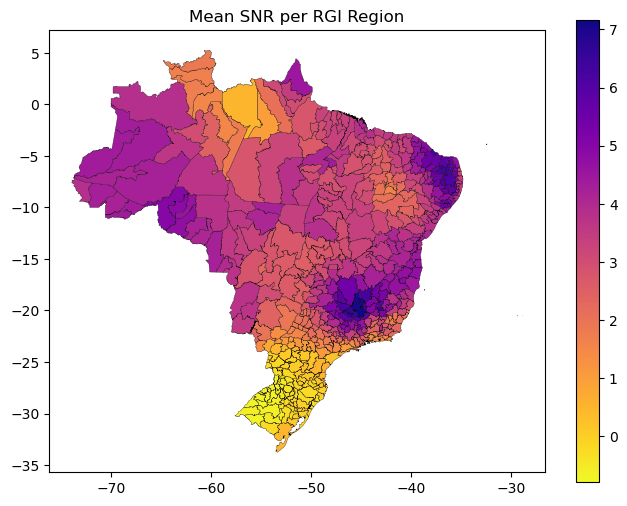

In [ ]:
# Plot 
shapefile.plot(
    column="snr_mean",
    cmap="plasma_r", # to match mortality plot (Figure 2 in main) 
    legend=True,
    figsize=(8, 6),
    edgecolor="black",
    linewidth=0.2
)
plt.title("Mean SNR per RGI Region")
plt.show()